# Симулятор газового куста

Демонстрация PVT-модели, пласта, гидравлики, рабочей точки, динамики, влияния ДКС и калибровки.

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

params = pd.read_csv('hw2_data.csv').iloc[0]
fluid = Fluid(M=params.M, rho_c=params.rho_c, xa=params.xa, xy=params.xy, T=310)

def build_simulator(CR=1.5, q_ext=500):
    reservoir = Reservoir(ResProps(P=100, V=math.pi * 500**2 * 25, T=310), fluid)
    well_specs = [(2000, 1800, 0.062), (2500, 1900, 0.062), (1800, 1600, 0.073)]
    wells = []
    for L, H, D in well_specs:
        pipe = Pipe(L=L, D=D, roughness=0.000046, fluid=fluid, vertical_depth=H)
        wells.append(Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=pipe))
    shlyf = Pipe(L=5000, D=0.2, roughness=0.000046, fluid=fluid)
    return FieldSimulator(reservoir, wells, shlyf, DCS(CR=CR, P_line=5, q_ext=q_ext))

simulator = build_simulator()

## 1. PVT-модель

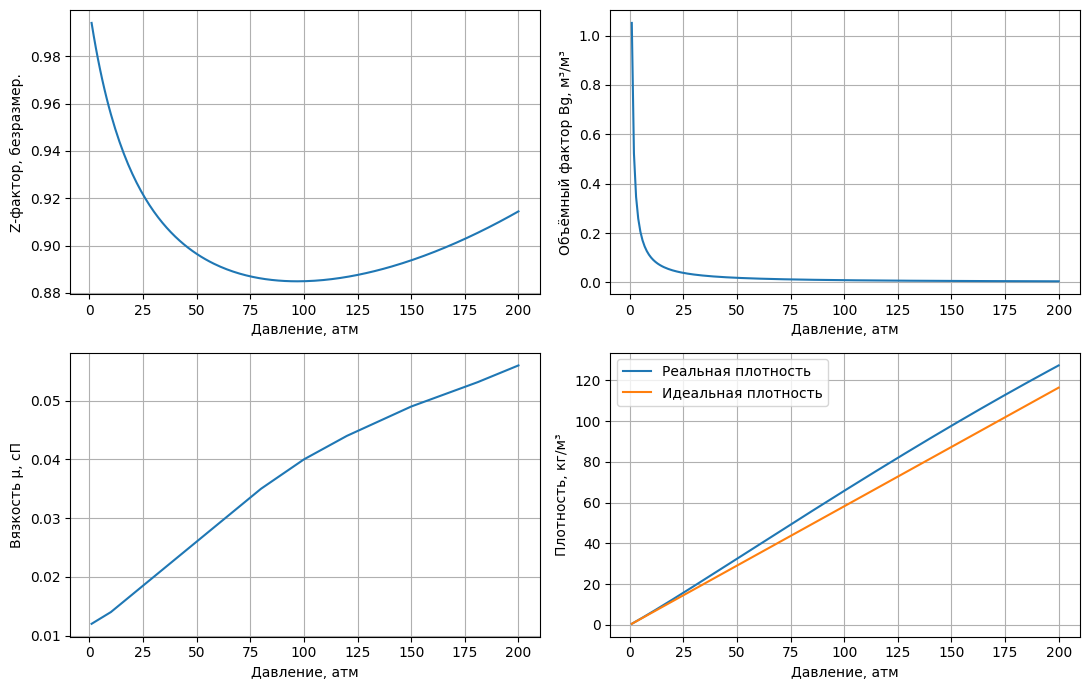

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

pressures = list(range(1, 201))

pvt = pd.DataFrame({
    'P': pressures,
    'Z': [fluid.z(p) for p in pressures],
    'Bg': [fluid.bg(p) for p in pressures],
    'mu': [fluid.mu(p) for p in pressures],
    'rho_real': [fluid.ro(p) for p in pressures],
    'rho_ideal': [p * fluid.ATM_TO_PA * fluid.M / (fluid.R * fluid.T) for p in pressures],
})

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# График 1: Z-фактор
pvt.plot(x='P', y='Z', ax=axes[0, 0], grid=True, legend=False)
axes[0, 0].set_xlabel('Давление, атм')
axes[0, 0].set_ylabel('Z-фактор, безразмер.')

# График 2: Объёмный фактор Bg
pvt.plot(x='P', y='Bg', ax=axes[0, 1], grid=True, legend=False)
axes[0, 1].set_xlabel('Давление, атм')
axes[0, 1].set_ylabel('Объёмный фактор Bg, м³/м³')

# График 3: Вязкость mu 
pvt.plot(x='P', y='mu', ax=axes[1, 0], grid=True, legend=False)
axes[1, 0].set_xlabel('Давление, атм')
axes[1, 0].set_ylabel('Вязкость μ, сП')

# График 4: Плотность (реальная и идеальная)
pvt.plot(x='P', y=['rho_real', 'rho_ideal'], ax=axes[1, 1], grid=True)
axes[1, 1].set_xlabel('Давление, атм')
axes[1, 1].set_ylabel('Плотность, кг/м³')
axes[1, 1].legend(['Реальная плотность', 'Идеальная плотность'])

plt.tight_layout()
plt.show()

## 2. Модель пласта

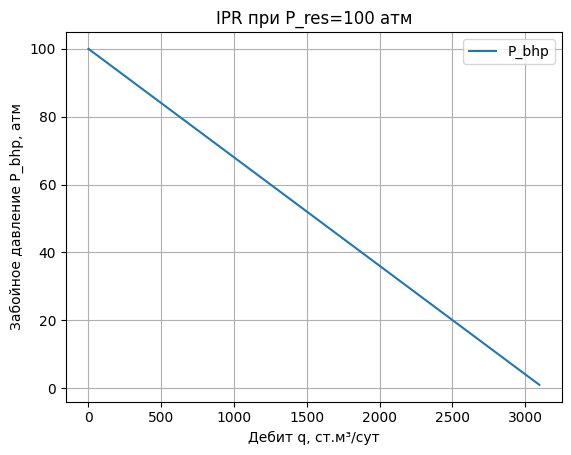

In [2]:
well = simulator.wells[0]
bhp = list(range(1, 101))
ipr = pd.DataFrame({'P_bhp': bhp, 'q': [well.q(100, p) for p in bhp]})

ipr.plot(x='q', y='P_bhp', grid=True, title='IPR при P_res=100 атм')
plt.xlabel('Дебит q, ст.м³/сут')
plt.ylabel('Забойное давление P_bhp, атм')
plt.show()

## 3. Гидравлика

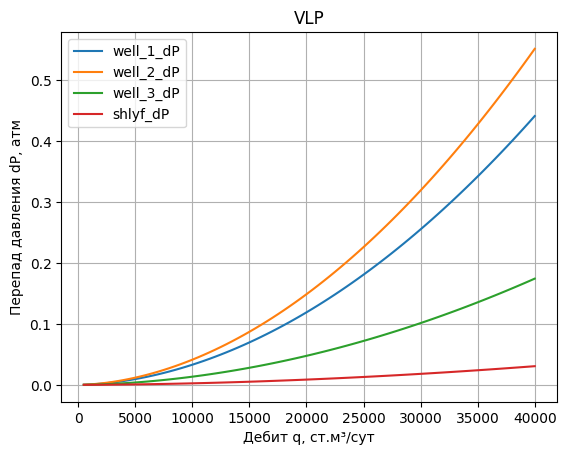

In [10]:
qs = list(range(500, 40001, 500))
vlp = pd.DataFrame({'q': qs})

for i, w in enumerate(simulator.wells, start=1):
    dp_friction_list = [] 
    for q in qs:
        state = w.pipe.dp(100, q)
        friction_pa = state.dP * w.pipe.fluid.ATM_TO_PA - w.pipe.fluid.ro(100) * 9.81 * w.pipe.vertical_depth
        dp_friction_list.append(friction_pa / w.pipe.fluid.ATM_TO_PA)
    vlp[f'well_{i}_dP'] = dp_friction_list  

vlp['shlyf_dP'] = [simulator.shlyf.dp(10, q).dP for q in qs]

import matplotlib.pyplot as plt
ax = vlp.plot(x='q', y=[c for c in vlp.columns if c != 'q'], grid=True, title='VLP')
ax.set_xlabel('Дебит q, ст.м³/сут')
ax.set_ylabel('Перепад давления dP, атм')
plt.show()

## 4. Рабочая точка

In [5]:
states = simulator.solve(100)
pd.DataFrame([s.__dict__ for s in states.values()])

,name,P_in,P_out,dP,q_std,q_res,v,rho
0,well_1,14.800606,3.338900,11.461706,2665.552930,24.943542,0.095625,65.751791
1,well_2,15.437916,3.338900,12.099017,2645.614008,24.756959,0.094910,65.751791
2,well_3,13.525647,3.338900,10.186747,2705.441371,25.316808,0.070010,65.751791
3,shlyf,3.338900,3.333333,0.005566,8516.608310,2648.337450,0.975685,1.978663
4,dcs,3.333333,5.000000,1.666667,8516.608310,NaN,NaN,NaN


## 5. Динамика

step 1/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 11/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 21/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 31/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 41/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 51/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 61/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 71/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 81/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 91/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 101/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 111/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 121/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 131/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 141/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 151/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 161/180: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 171/180: P_res=100.0

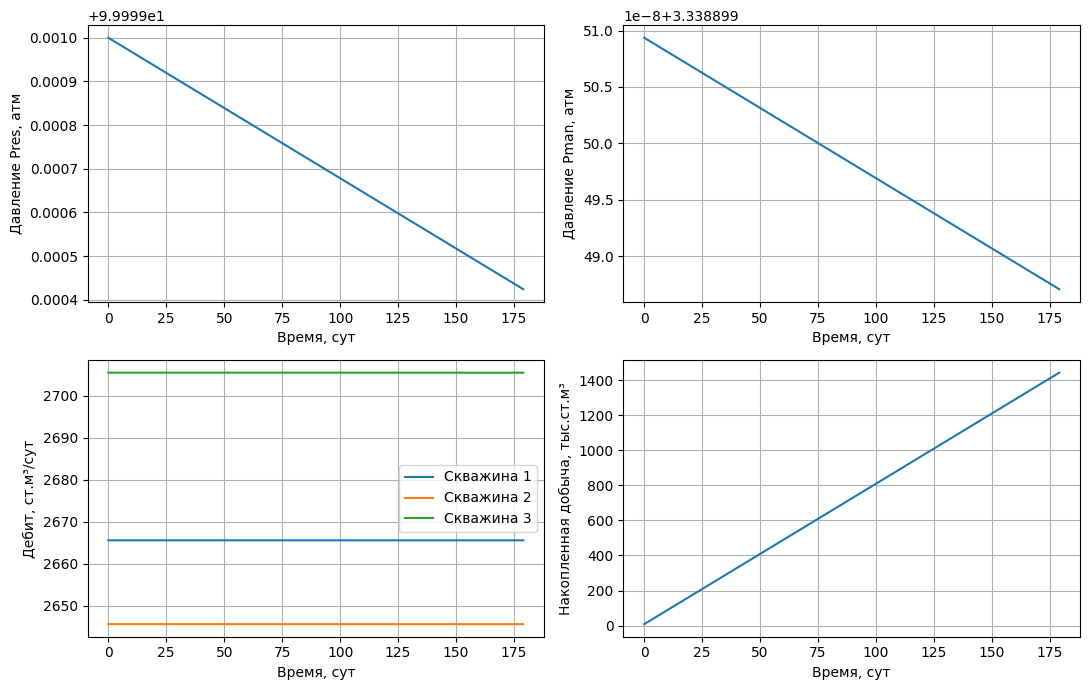

In [16]:
simulator = build_simulator()
df = simulator.run(180, dt=1)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# График 1: Пластовое давление
df.plot(x='t', y='P_res', ax=axes[0, 0], grid=True, legend=False)
axes[0, 0].set_xlabel('Время, сут')
axes[0, 0].set_ylabel('Давление Pres, атм')

# График 2: Давление на манифольде
df.plot(x='t', y='P_man', ax=axes[0, 1], grid=True, legend=False)
axes[0, 1].set_xlabel('Время, сут')
axes[0, 1].set_ylabel('Давление Pman, атм')

# График 3: Дебиты скважин
df.plot(x='t', y=['q1', 'q2', 'q3'], ax=axes[1, 0], grid=True)
axes[1, 0].set_xlabel('Время, сут')
axes[1, 0].set_ylabel('Дебит, ст.м³/сут')
axes[1, 0].legend(['Скважина 1', 'Скважина 2', 'Скважина 3'])

# График 4: Накопленная добыча
df.plot(x='t', y='Gp', ax=axes[1, 1], grid=True, legend=False)
axes[1, 1].set_xlabel('Время, сут')
axes[1, 1].set_ylabel('Накопленная добыча, тыс.ст.м³')

plt.tight_layout()
plt.show()

## 6. Влияние ДКС

step 1/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 11/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 21/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 31/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 41/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 51/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 61/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 71/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 81/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 91/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 101/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 111/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 121/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 131/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 141/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 151/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 161/180: P_res=100.00 atm, q_total=7860.4 std.m3/day
step 171/180: P_res=100.0

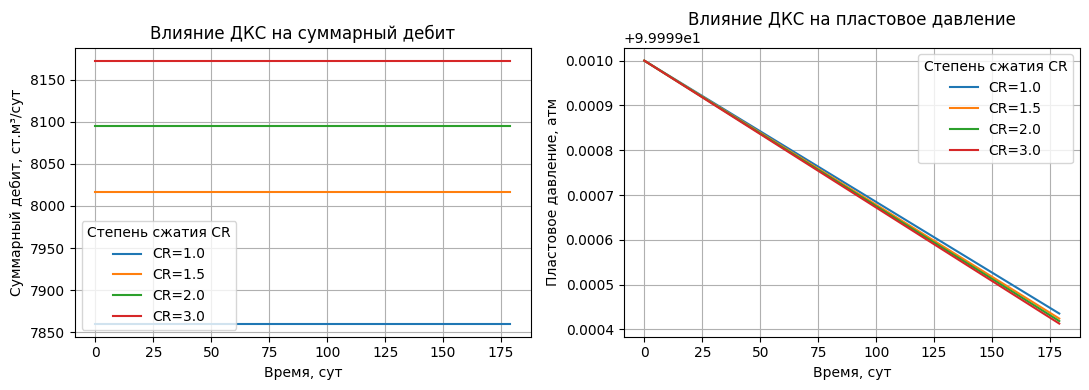

In [19]:
cr_runs = []
for cr in [1.0, 1.5, 2.0, 3.0]:
    run = build_simulator(CR=cr).run(180, dt=1)
    run['CR'] = cr
    cr_runs.append(run)
cr_df = pd.concat(cr_runs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# График 1: Влияние ДКС на суммарный дебит
for cr, grp in cr_df.groupby('CR'):
    grp.plot(x='t', y='q_total', ax=axes[0], label=f'CR={cr}', grid=True)
axes[0].set_xlabel('Время, сут')
axes[0].set_ylabel('Суммарный дебит, ст.м³/сут')
axes[0].set_title('Влияние ДКС на суммарный дебит')
axes[0].legend(title='Степень сжатия CR')

# График 2: Влияние ДКС на пластовое давление
for cr, grp in cr_df.groupby('CR'):
    grp.plot(x='t', y='P_res', ax=axes[1], label=f'CR={cr}', grid=True)
axes[1].set_xlabel('Время, сут')
axes[1].set_ylabel('Пластовое давление, атм')
axes[1].set_title('Влияние ДКС на пластовое давление')
axes[1].legend(title='Степень сжатия CR')

plt.tight_layout()
plt.show()

## 7. Калибровка

step 1/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 11/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 21/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 31/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 41/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 51/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 61/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 71/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 81/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 91/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 101/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 111/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 121/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 131/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 141/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 151/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 161/181: P_res=100.00 atm, q_total=8016.6 std.m3/day
step 171/181: P_res=100.0

<Axes: title={'center': 'Модель vs Фактическая добыча'}, xlabel='date'>

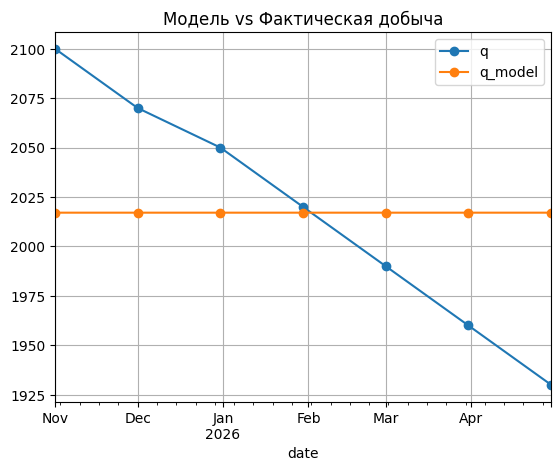

In [20]:
fact = pd.read_csv('adapt_gdi_11-2025.csv')
fact['date'] = pd.to_datetime(fact['date'])
fact['day'] = (fact['date'] - fact['date'].min()).dt.days

base_k = 50

def run_for_multiplier(multiplier):
    sim = build_simulator()
    for w in sim.wells:
        w.k = base_k * float(multiplier)
    return sim.run(int(fact['day'].max()) + 1, dt=1)

def objective(x):
    mult = max(float(x[0]), 0.01)
    model = run_for_multiplier(mult)
    model_points = model[model['t'].isin(fact['day'])][['t', 'q_total']].rename(columns={'t': 'day', 'q_total': 'q_model'})
    joined = fact.merge(model_points, on='day')
    return ((joined['q'] - joined['q_model']) ** 2).mean() ** 0.5

result = minimize(objective, x0=[1.0], method='Nelder-Mead')
best_multiplier = max(float(result.x[0]), 0.01)
best_model = run_for_multiplier(best_multiplier)
model_points = best_model[best_model['t'].isin(fact['day'])][['t', 'q_total']].rename(columns={'t': 'day', 'q_total': 'q_model'})
cal = fact.merge(model_points, on='day')
err = cal['q'] - cal['q_model']
rmse = (err.pow(2).mean()) ** 0.5
r2 = 1 - err.pow(2).sum() / (cal['q'] - cal['q'].mean()).pow(2).sum()
print(f'C multiplier={best_multiplier:.4f}, RMSE={rmse:.2f}, R2={r2:.4f}')
cal.plot(x='date', y=['q', 'q_model'], marker='o', grid=True, title='Модель vs Фактическая добыча')